# Week 8 Seminar

**Chapter 3. Bayesian Inference. [CASI](https://web.stanford.edu/~hastie/CASI_files/PDF/casi.pdf) & [BDA](https://users.aalto.fi/~ave/BDA3.pdf) textbooks**

**Course:** ML1, 2025/2026, HSE

**Author:** Alexey Boldyrev, Aleksandr Khizhik, Teaching Team.

# Setup <a id="setup"></a>

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy

import statsmodels.api as sm
from statsmodels.nonparametric.smoothers_lowess import lowess

from scipy import stats

# RNG: single source of randomness
RNG = np.random.default_rng(2025)

# Pretty printing
np.set_printoptions(suppress=True, precision=4)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# Plot defaults
FIGSIZE = (8, 6)
plt.rcParams.update({
    "figure.figsize": FIGSIZE,
    "axes.grid": True,
    "grid.alpha": 0.3
})

# Version stamp for reproducibility
def _versions():
    import sys, matplotlib
    print("Python:", sys.version.split()[0])
    print("NumPy:", np.__version__)
    print("Pandas:", pd.__version__)
    print("SciPy:", scipy.__version__)
    print("Statsmodels:", sm.__version__)
    print("Matplotlib:", matplotlib.__version__)

_versions()

Python: 3.12.11
NumPy: 2.3.3
Pandas: 2.3.3
SciPy: 1.16.2
Statsmodels: 0.14.5
Matplotlib: 3.10.6


# Fundamentals of Frequentist, Bayesian (and Fisherian) Inference <a id="fundamentals"></a>
Statistical analysis:
- **Algorithm** (what we compute), e.g., the mean: $\bar{x}=\sum_{i=1}^n x_i/n$.
- **Inference** (why we trust it), e.g., the standard error:
  $\widehat{\mathrm{se}}=\sqrt{\frac{\sum_{i=1}^n (x_i-\bar{x})^2}{n(n-1)}}$.

"Inference" concerns more than accuracy: algorithms say **what** we do; inference says **why** it’s reasonable.

Of course, $\widehat{\mathrm{se}}$ is itself an algorithm, which could be (and is) subject to further inferential analysis concerning its accuracy.

**Notation.**
- Distributions: $\mathcal{N}$ (Normal), $\mathcal{U}$ (Uniform), $\mathcal{B}$ (Beta), etc.
- Vectors: $\mathbf{x}$ or $\boldsymbol{x}$; Matrices in bold caps, e.g., $\mathbf{X}$.

# Linear regression: inference & uncertainty <a id="linear-regression"></a>

**What we'll do now**
- Fit a simple OLS: `tot ~ age` on the Stanford kidney data.
- Compare **hand-computed fitted-line SEs** with `statsmodels` **mean CIs**.
- Add **prediction intervals** for new observations.
- Examine **heteroskedasticity-robust (HC3)** SEs and visualize a robust mean band.

In [ ]:
# Load dataset (Stanford CASI "kidney.txt")
kidney_url = "https://web.stanford.edu/~hastie/CASI_files/DATA/kidney.txt"
df = pd.read_csv(kidney_url, sep=' ')
df.head()

,age,tot
0,18,2.4400
1,19,3.8600
2,19,-1.2200
3,20,2.3000
4,21,0.9800


## OLS fit

In [ ]:
X = sm.add_constant(df["age"])
y = df["tot"].to_numpy()
ols = sm.OLS(y, X).fit()
print("Coefficients [intercept, age]:", ols.params.values)

Coefficients [intercept, age]: [ 2.8600268  -0.07858842]


## Fitted-line uncertainty: hand SEs vs. `statsmodels`
For a new row $\mathbf{x}_0=[1,\,\text{age}_0]$, the variance of the fitted **mean** is
$$\mathrm{Var}(\hat{y}_0)=\mathbf{x}_0^\top\,\mathrm{Cov}(\hat{\boldsymbol{\beta}})\,\mathbf{x}_0.$$
We compare this hand calculation to `statsmodels.get_prediction(...).summary_frame()`,
which provides 95% **mean CIs** and **prediction intervals**.

In [ ]:
# Grid for predictions across the observed age range
x_grid = np.linspace(df.age.min(), df.age.max(), 60)
X0 = sm.add_constant(x_grid)

In [ ]:
def fitted_line_se(result, X0, cov=None):
    """
    Hand-compute SE of fitted mean at X0 rows using covariance of params.
    Parameters
    ----------
    result : statsmodels RegressionResults
    X0 : array-like with intercept column (n0 x p)
    cov : optional covariance matrix to use (e.g., robust). Defaults to result.cov_params()
    Returns
    -------
    se_mean : (n0,) array of standard errors for the fitted mean
    """
    V = result.cov_params() if cov is None else cov
    X0 = np.asarray(X0)
    # Var( X0 b̂ ) = diag( X0 V X0^T )
    se2 = np.einsum("ij,jk,ik->i", X0, V, X0)
    return np.sqrt(se2)

# Hand-computed SE of fitted mean
se_mean_hand = fitted_line_se(ols, X0)
se_mean_hand

array([0.22002161, 0.21200331, 0.20423559, 0.19674812, 0.18957411,
       0.18275048, 0.17631791, 0.17032073, 0.16480645, 0.15982509,
       0.15542788, 0.15166564, 0.14858661, 0.14623396, 0.14464313,
       0.1438394 , 0.14383597, 0.14463289, 0.14621708, 0.14856335,
       0.15163634, 0.15539294, 0.15978493, 0.16476151, 0.17027144,
       0.17626471, 0.18269374, 0.1895142 , 0.19668538, 0.20417032,
       0.21193577, 0.21995204, 0.22819269, 0.23663427, 0.24525605,
       0.25403967, 0.26296893, 0.27202947, 0.2812086 , 0.2904951 ,
       0.29987898, 0.30935137, 0.3189044 , 0.32853103, 0.33822497,
       0.34798061, 0.35779288, 0.36765726, 0.37756967, 0.38752642,
       0.39752417, 0.40755991, 0.4176309 , 0.42773465, 0.4378689 ,
       0.44803157, 0.45822077, 0.46843477, 0.47867199, 0.48893096])

In [ ]:
# statsmodels prediction summary (mean CI + prediction band)
pred = ols.get_prediction(X0).summary_frame(alpha=0.05)  # 95%
pred.head()

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,1.4454,0.2200,1.0108,1.8801,-2.1387,5.0296
1,1.3522,0.2120,0.9334,1.7710,-2.2301,4.9345
2,1.2590,0.2042,0.8555,1.6624,-2.3216,4.8395
3,1.1657,0.1967,0.7771,1.5544,-2.4132,4.7446
4,1.0725,0.1896,0.6980,1.4470,-2.5049,4.6498


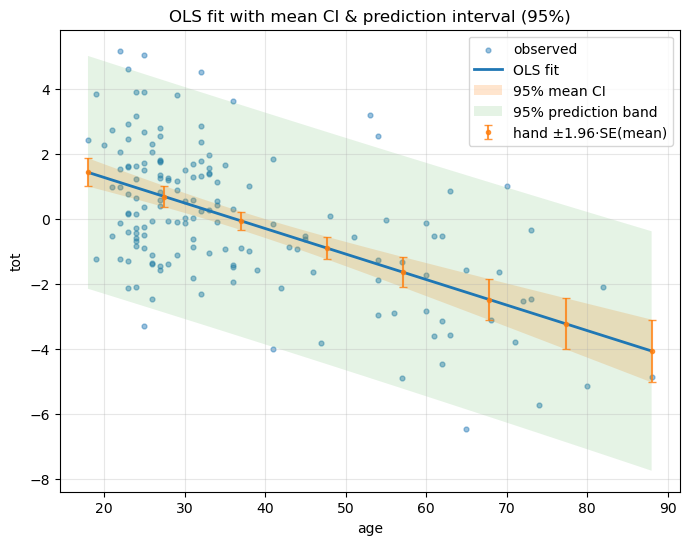

In [ ]:
# Plot: data, fit, 95% mean CI, 95% prediction interval
fig, ax = plt.subplots()

ax.scatter(df.age, df.tot, s=12, alpha=0.45, label="observed")

ax.plot(x_grid, pred["mean"], lw=2, label="OLS fit")
ax.fill_between(x_grid, pred["mean_ci_lower"], pred["mean_ci_upper"], alpha=0.2, label="95% mean CI")
ax.fill_between(x_grid, pred["obs_ci_lower"], pred["obs_ci_upper"], alpha=0.12, label="95% prediction band")

# Also show hand SE as error bars at sparse points to compare
ix = np.linspace(0, len(x_grid)-1, 8, dtype=int)
ax.errorbar(x_grid[ix], pred["mean"].to_numpy()[ix], yerr=1.96*se_mean_hand[ix],
            fmt=".", capsize=3, alpha=0.8, label="hand ±1.96·SE(mean)")

ax.legend()
ax.set_xlabel("age")
ax.set_ylabel("tot")
ax.set_title("OLS fit with mean CI & prediction interval (95%)")

plt.show()

The linear regression shows estimate 1.29 at age 20, down to -3.43 at age 80. How accurate are these estimates?

This is where **inference** comes in.

**Takeaways.** The **mean confidence band** (narrower) quantifies uncertainty of the fitted line;
the **prediction band** (wider) adds irreducible noise. The hand-computed SEs match the
`statsmodels` mean CI, validating our matrix formula $\,\mathrm{Var}(\hat{y}_0)=\mathbf{x}_0^\top \mathrm{Cov}(\hat{\boldsymbol{\beta}})\mathbf{x}_0$.

## Heteroskedasticity-robust SEs (HC3)
If the error variance changes with age, classical SEs can be misleading.
HC3 adjusts $\mathrm{Cov}(\hat{\boldsymbol{\beta}})$ without changing $\hat{\boldsymbol{\beta}}$.

In [ ]:
ols_hc3 = ols.get_robustcov_results(cov_type="HC3")

print("Std. errors (classical):", np.sqrt(np.diag(ols.cov_params())))
print("Std. errors (HC3)     :", np.sqrt(np.diag(ols_hc3.cov_params())))

Std. errors (classical): [0.35956457 0.0090558 ]
Std. errors (HC3)     : [0.37149401 0.00973418]


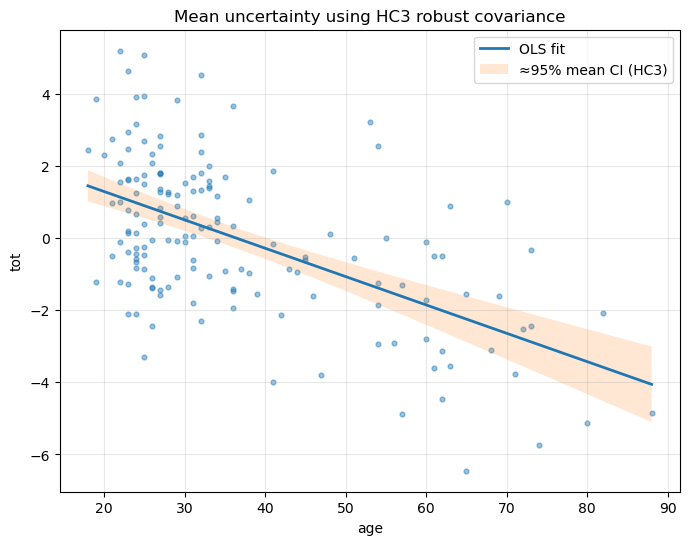

In [ ]:
# Use robust Cov(β̂) to build an approximate robust mean band
se_mean_hc3 = fitted_line_se(ols, X0, cov=ols_hc3.cov_params())

fig, ax = plt.subplots()
ax.scatter(df.age, df.tot, s=12, alpha=0.45)
ax.plot(x_grid, pred["mean"], lw=2, label="OLS fit")

ax.fill_between(x_grid,
                pred["mean"] - 1.96 * se_mean_hc3,
                pred["mean"] + 1.96 * se_mean_hc3,
                alpha=0.18, label="≈95% mean CI (HC3)")

ax.legend()
ax.set_title("Mean uncertainty using HC3 robust covariance")
ax.set_xlabel("age")
ax.set_ylabel("tot")
plt.show()

**Takeaways.** When heteroskedasticity is plausible, report **HC3** (or related HC) SEs.
Parameter SEs (and thus mean-CI width) can change meaningfully even when coefficients don't.
Robust bands reflect parameter-uncertainty under variance misspecification; prediction bands still include noise.

# Local polynomial fit (LOWESS) + bootstrap <a id="lowess"></a>

**What we'll do now**
- Fit a LOWESS smoother to `tot ~ age` to capture nonlinearity without a parametric form.
- Use the bootstrap to visualize **uncertainty** (no simple closed-form SE for LOWESS).
- Build **pointwise 95% bootstrap bands** by interpolating bootstrap smooths to a common grid.

**Why LOWESS?** Locally weighted regressions reduce bias in regions where a straight line is inadequate,
at the cost of increased variance. Bootstrap replicates reveal that variance visually.

In [ ]:
# Single LOWESS fit
w = lowess(df.tot, df.age,
           frac=1/3,  # frac is the fraction of data used in estimating each y value
           return_sorted=True)

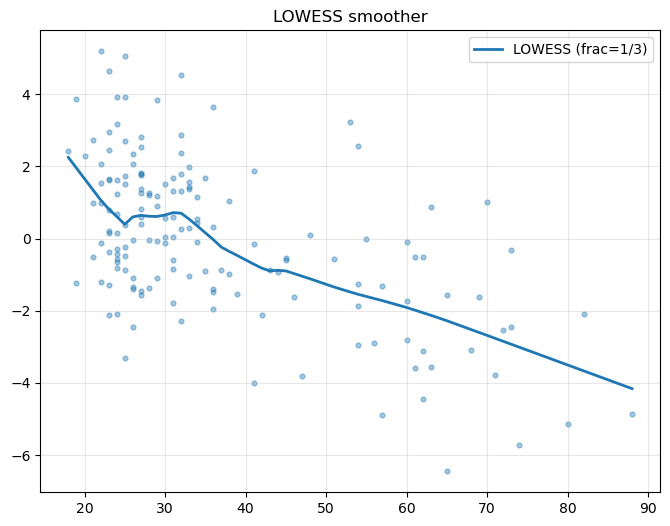

In [ ]:
fig, ax = plt.subplots()
ax.scatter(df.age, df.tot, s=12, alpha=0.4)
ax.plot(w[:, 0], w[:, 1], lw=2, label="LOWESS (frac=1/3)")
ax.legend()
ax.set_title("LOWESS smoother")
plt.show()

## Bootstrap LOWESS: visualizing uncertainty
There is no formula such as for the standard error to infer the accuracy of the LOWESS curve. Instead bootstrap is used.

We resample rows with replacement, refit LOWESS on each bootstrap sample,
and **interpolate** the resulting curves to a common age grid to compute pointwise quantiles.

In [ ]:
def lowess_fit(x, y, *, frac=1/3):
    """
    Return sorted LOWESS curve as (x_smooth, y_smooth).
    'frac' is the proportion of data used for each local neighborhood.
    """
    w = lowess(y, x, frac=frac, return_sorted=True)
    return w[:, 0], w[:, 1]

def bootstrap_lowess(
    df, x_col="age", y_col="tot", *, frac=1/3, B=200, grid=None, rng=None
):
    """
    Bootstrap LOWESS curves.
    Returns:
        grid : (m,) array of x-values
        y_hat : (m,) LOWESS on the original data (for reference)
        boots : (B, m) array of bootstrap-smoothed values interpolated on 'grid'
    Notes:
        - We interpolate each bootstrap curve onto 'grid' to enable pointwise quantiles.
        - We keep the grid within the observed x-range to avoid extrapolation artifacts.
    """
    if rng is None:
        rng = np.random.default_rng()
    x = df[x_col].to_numpy()
    y = df[y_col].to_numpy()

    # Reference LOWESS on original data
    x_ref, y_ref = lowess_fit(x, y, frac=frac)

    # Common grid: inside observed support
    if grid is None:
        x_min = np.min(x_ref)
        x_max = np.max(x_ref)
        grid = np.linspace(x_min, x_max, 200)

    # Container for bootstrap smooths on the common grid
    boots = np.empty((B, grid.size), dtype=float)

    n = len(df)
    for b in range(B):
        # Resample indices with replacement
        idx = rng.integers(0, n, n)
        xb, yb = x[idx], y[idx]

        # LOWESS on the bootstrap sample
        xs_b, ys_b = lowess_fit(xb, yb, frac=frac)

        # Interpolate onto the common grid; outside range -> NaN
        yb_grid = np.interp(grid, xs_b, ys_b, left=np.nan, right=np.nan)
        boots[b, :] = yb_grid

    # Interpolate original fit onto grid too (for overlay)
    y_ref_grid = np.interp(grid, x_ref, y_ref)
    return grid, y_ref_grid, boots

In [ ]:
# Compute bootstrap objects (200 replicates for stable quantiles)
grid, y_ref_grid, boots = bootstrap_lowess(df, frac=1/3, B=200, rng=RNG)

# Pointwise 95% bootstrap band using nan-aware percentiles
lo = np.nanpercentile(boots, 2.5, axis=0)
hi = np.nanpercentile(boots, 97.5, axis=0)

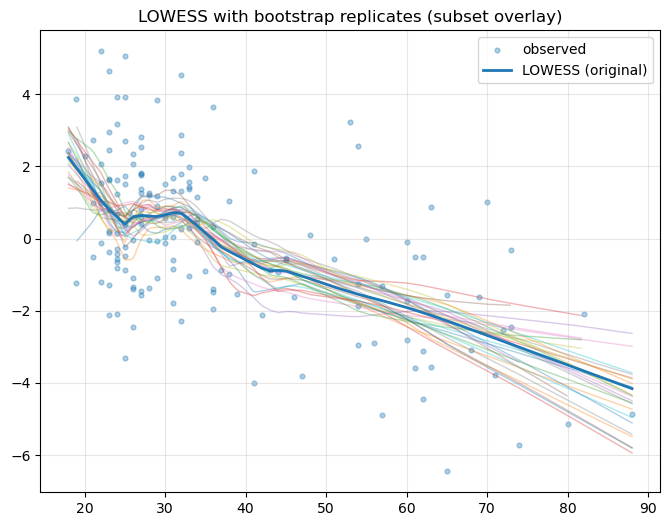

In [ ]:
# Bootstrap curves
fig, ax = plt.subplots()
ax.scatter(df.age, df.tot, s=12, alpha=0.35, label="observed")

# Draw only a subset to avoid clutter
subset = 30
choose = RNG.choice(boots.shape[0], size=subset, replace=False)
for b in choose:
    ax.plot(grid, boots[b], lw=1, alpha=0.35)

ax.plot(grid, y_ref_grid, lw=2, label="LOWESS (original)")
ax.legend()
ax.set_title("LOWESS with bootstrap replicates (subset overlay)")
plt.show()

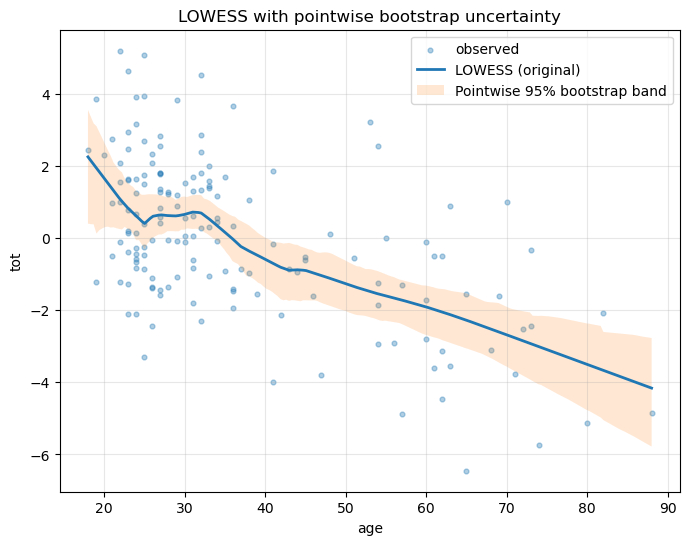

In [ ]:
# Pointwise 95% bootstrap band
fig, ax = plt.subplots()
ax.scatter(df.age, df.tot, s=12, alpha=0.35, label="observed")

ax.plot(grid, y_ref_grid, lw=2, label="LOWESS (original)")
ax.fill_between(grid, lo, hi, alpha=0.18, label="Pointwise 95% bootstrap band")

ax.legend()
ax.set_title("LOWESS with pointwise bootstrap uncertainty")
ax.set_xlabel("age")
ax.set_ylabel("tot")

plt.show()

**Takeaways.** LOWESS captures smooth structure without specifying a parametric form; uncertainty comes from resampling, not a closed-form variance. The overlay shows how wiggly the smoother can be under data perturbations; the ribbon summarizes pointwise variability: narrow where the signal is strong/dense, wider near edges or sparse regions.

# Probability distributions in Python <a id="dists"></a>

**What we'll do now**
- Learn the *API pattern* for distributions in SciPy (`pdf/pmf`, `cdf`, `ppf`, `rvs`, `stats`).
- Work with two canonical cases: **Normal** $\mathcal{N}(\mu,\sigma^2)$ and **Poisson** $\mathcal{P}(\lambda)$.
- Make **reproducible** simulations (single RNG) and **consistent** plots you can read at a glance.

**Why this matters.** Modeling begins with the right distributional assumptions.
Being fluent with SciPy’s API lets you compute probabilities, quantiles, and simulate data, all the pieces
you need for inference and visualization later.

### Normal distribution $\mathcal{N}(\mu,\sigma^2)$

**Goal.** Read the docs, compute moments, plot the PDF, and compare to a sample histogram.

In [ ]:
# help(stats.norm)

In [ ]:
# First four moments of the standard Normal
mean, var, skew, kurt = stats.norm.stats(moments="mvsk")
print(f"mean: {mean}, var: {var}, skew: {skew}, kurt: {kurt}")

mean: 0.0, var: 1.0, skew: 0.0, kurt: 0.0


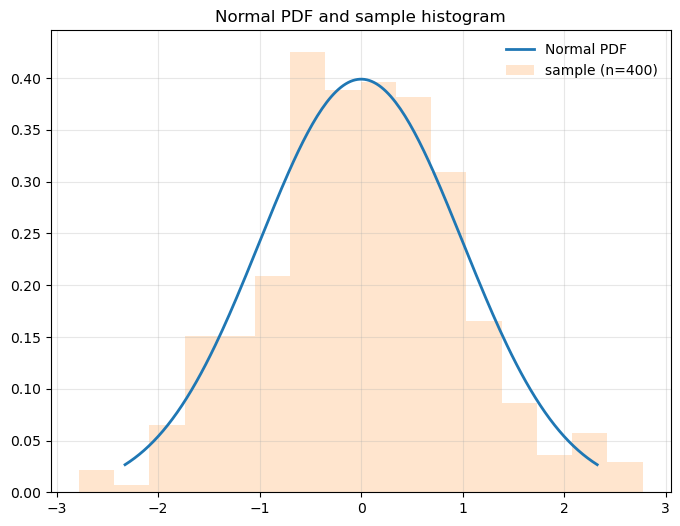

In [ ]:
def _grid_from_ppf(dist, qlo=0.01, qhi=0.99, n=300, **kwargs):
    """Evenly spaced x-grid between given quantiles for a continuous dist."""
    lo, hi = dist.ppf([qlo, qhi], **kwargs)
    return np.linspace(lo, hi, n)

# PDF on a central grid (1%..99% quantiles)
x = _grid_from_ppf(stats.norm, qlo=0.01, qhi=0.99, n=200)
pdf_vals = stats.norm.pdf(x)

# Simulate draws (reproducible)
r = stats.norm.rvs(size=400, random_state=RNG)

fig, ax = plt.subplots()
ax.plot(x, pdf_vals, lw=2, label="Normal PDF")
ax.hist(r, bins="auto", density=True, histtype="stepfilled", alpha=0.2, label="sample (n=400)")
ax.legend(frameon=False)
ax.set_title("Normal PDF and sample histogram")
plt.show()

**How to read this plot.** The curve is the theoretical density; the histogram approximates it from data.
With $n=400$, the sample is still a bit jagged, it is expected random variation.

In [ ]:
# Quick API demo: cdf/ppf consistency
vals = stats.norm.ppf([0.001, 0.5, 0.999])
print("Check cdf(ppf(p))≈p:", np.allclose([0.001, 0.5, 0.999], stats.norm.cdf(vals)))

Check cdf(ppf(p))≈p: True


### Poisson distribution $\mathcal{P}(\lambda)$

**Goal.** Compute moments, plot the PMF, and simulate draws for a discrete distribution.

In [ ]:
# help(stats.poisson)

In [ ]:
lam = 0.6
mean, var, skew, kurt = stats.poisson.stats(lam, moments="mvsk")
print(f"mean: {mean}, var: {var}, skew: {skew}, kurt: {kurt}")

mean: 0.5, var: 0.5, skew: 1.4142135623730951, kurt: 2.0


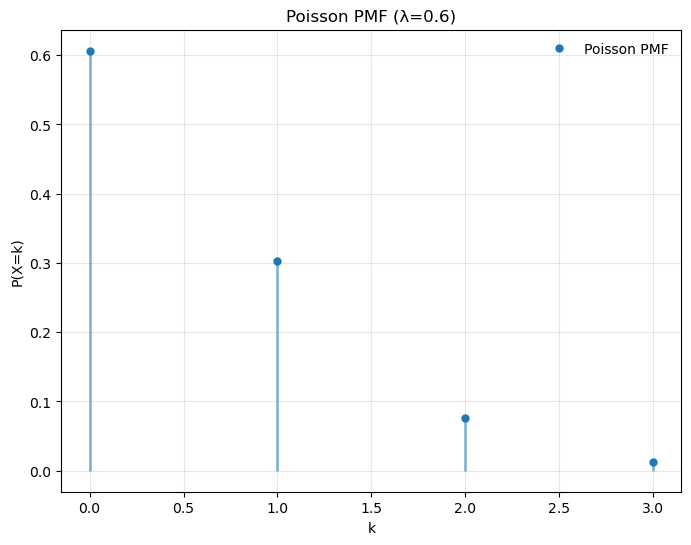

In [ ]:
# Discrete support from 1%..99% quantiles
xk = np.arange(stats.poisson.ppf(0.01, lam), stats.poisson.ppf(0.99, lam) + 1)
pmf_vals = stats.poisson.pmf(xk, lam)

fig, ax = plt.subplots()
ax.plot(xk, pmf_vals, "o", ms=5, label="Poisson PMF")
ax.vlines(xk, 0, pmf_vals, lw=2, alpha=0.5)
ax.set_title("Poisson PMF (λ=0.6)")
ax.set_xlabel("k")
ax.set_ylabel("P(X=k)")
ax.legend(frameon=False)
plt.show()

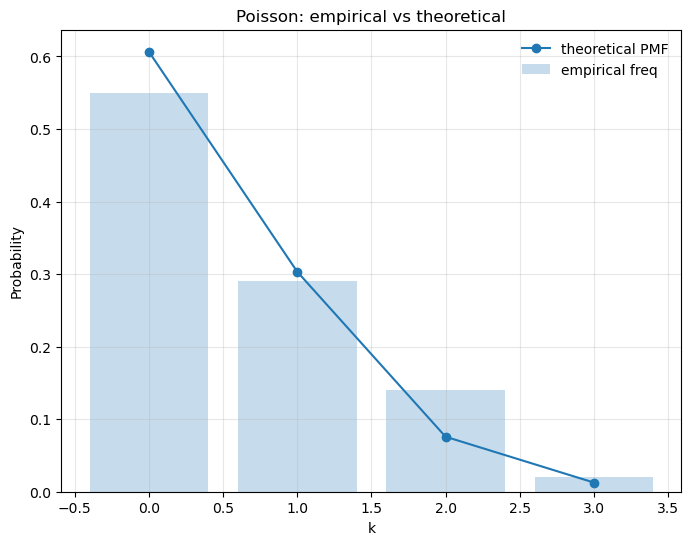

In [ ]:
# Simulate draws and compare empirical frequencies to PMF
r_disc = stats.poisson.rvs(lam, size=100, random_state=RNG)
fig, ax = plt.subplots()
# empirical frequencies
vals, counts = np.unique(r_disc, return_counts=True)
ax.bar(vals, counts / r_disc.size, alpha=0.25, label="empirical freq")
ax.plot(xk, pmf_vals, "o-", lw=1.5, label="theoretical PMF")
ax.set_title("Poisson: empirical vs theoretical")
ax.set_xlabel("k")
ax.set_ylabel("Probability")
ax.legend(frameon=False)
plt.show()

**Takeaways.** SciPy's distribution objects follow a consistent pattern, once you know pdf/pmf, cdf, ppf, rvs, and stats, you can work with virtually any common distribution. Use ppf bounds to pick sensible plotting ranges, a single RNG for reproducibility, and keep visuals standardized so comparisons across distributions are easy.

# Bayesian Data Analysis <a id="bayes"></a>

**What we'll do now**
- State **Bayes' rule** and clarify the roles of the *prior*, *likelihood*, *posterior*, and *marginal likelihood*.
- Recall **common distributions**.

**Why this matters.** Bayes’ rule scaffolds the posterior updates we'll implement in upcoming examples.

## Notations

- Parameters (unknowns): $\boldsymbol{\theta}$ (vector), or $\theta$ (scalar).
- Observed data: $y$ (scalar), $\boldsymbol{y}$ (vector), $\mathbf{Y}$ (matrix).
- Replicated/future data: $\tilde{y}$.
- Probability **density** (continuous) / **mass** (discrete): generically $p(\cdot)$; probability of events: $\Pr(\cdot)$.
- Conditional / marginal: $p(\cdot\mid\cdot)$, $p(\cdot)$.
- Distribution: $\mathcal{N}$ (Normal), $\mathcal{U}$ (Uniform), $\mathcal{B}$ (Beta), etc.; vectors/matrices ($\boldsymbol{x}$, $\mathbf{X}$).

## Bayes' rule (mechanics of updating)

With prior $p(\boldsymbol{\theta})$ and sampling model (likelihood) $p(\boldsymbol{y}\mid\boldsymbol{\theta})$:

- **Joint:** $p(\boldsymbol{\theta},\boldsymbol{y}) = p(\boldsymbol{\theta})\,p(\boldsymbol{y}\mid\boldsymbol{\theta})$  
- **Posterior:** $p(\boldsymbol{\theta}\mid\boldsymbol{y}) = \dfrac{p(\boldsymbol{\theta})\,p(\boldsymbol{y}\mid\boldsymbol{\theta})}{p(\boldsymbol{y})}$  
- **Marginal likelihood (evidence):** $p(\boldsymbol{y})=\displaystyle\int p(\boldsymbol{\theta})\,p(\boldsymbol{y}\mid\boldsymbol{\theta})\,d\boldsymbol{\theta}$

**Likelihood function.** For fixed data $\boldsymbol{y}$, the likelihood is  
$$L_{\boldsymbol{y}}(\boldsymbol{\theta}) \equiv p(\boldsymbol{y}\mid\boldsymbol{\theta}),$$
viewed as a function of $\boldsymbol{\theta}$. Bayes updates multiply **prior × likelihood**, then renormalize.

## Common distributions

**Goal.** Quick, accurate reference for notation, support, parameters, and the pdf/pmf forms you'll use in priors/likelihoods.

### Continuous

| Distribution | Notation | Support | Parameters | Density $f(x)$ |
|---|---|---|---|---|
| Uniform | $X \sim \mathcal{U}(\alpha,\beta)$ | $x \in [\alpha,\beta]$ | $\alpha<\beta$ | $f(x)=\dfrac{1}{\beta-\alpha}$ on $[\alpha,\beta]$, else $0$. |
| Normal (Gaussian) | $X \sim \mathcal{N}(\mu,\sigma^2)$ | $x\in\mathbb{R}$ | $\sigma>0$ | $f(x)=\dfrac{1}{\sqrt{2\pi\sigma^2}}\exp\!\Big(-\dfrac{(x-\mu)^2}{2\sigma^2}\Big)$. |
| Lognormal | $X \sim \mathcal{LN}(\mu,\sigma^2)$ | $x>0$ | $\log X \sim \mathcal{N}(\mu,\sigma^2)$ | $f(x)=\dfrac{1}{x\,\sigma\sqrt{2\pi}}\exp\!\Big(-\dfrac{(\ln x-\mu)^2}{2\sigma^2}\Big)$. |
| Multivariate Normal | $\boldsymbol{X}\sim \mathcal{N}_k(\boldsymbol{\mu},\mathbf{\Sigma})$ | $\boldsymbol{x}\in\mathbb{R}^k$ | $\mathbf{\Sigma}\succ 0$ | $f(\boldsymbol{x})=\dfrac{1}{(2\pi)^{k/2}|\mathbf{\Sigma}|^{1/2}}\exp\!\Big(-\tfrac12(\boldsymbol{x}-\boldsymbol{\mu})^\top \mathbf{\Sigma}^{-1}(\boldsymbol{x}-\boldsymbol{\mu})\Big)$. |
| Gamma (shape–rate) | $X \sim \mathrm{Ga}(\alpha,\beta)$ | $x>0$ | $\alpha>0,\ \beta>0$ | $f(x)=\dfrac{\beta^\alpha}{\Gamma(\alpha)}\,x^{\alpha-1}e^{-\beta x}$. *(Alt. shape–scale uses $\theta=1/\beta$).* |
| Chi-square | $X \sim \chi^2_\nu$ | $x>0$ | $\nu>0$ | $f(x)=\dfrac{x^{\nu/2-1}e^{-x/2}}{2^{\nu/2}\Gamma(\nu/2)}$. *(Equivalently $\chi^2_\nu=\mathrm{Ga}(\nu/2,\ \beta=\tfrac12)$).* |
| Student-$t$ (standard) | $T \sim t_\nu$ | $t\in\mathbb{R}$ | $\nu>0$ | $f(t)=\dfrac{\Gamma((\nu+1)/2)}{\sqrt{\pi\nu}\,\Gamma(\nu/2)}\Big(1+\dfrac{t^2}{\nu}\Big)^{-(\nu+1)/2}$. |
| Student-$t$ (location–scale) | $X=\mu+\sigma T,\ T\sim t_\nu$ | $x\in\mathbb{R}$ | $\sigma>0,\ \nu>0$ | $f(x)=\dfrac{1}{\sigma}\,f_{t_\nu}\!\Big(\dfrac{x-\mu}{\sigma}\Big)$. |
| Beta | $X \sim \mathcal{B}(\alpha,\beta)$ | $x\in(0,1)$ | $\alpha>0,\ \beta>0$ | $f(x)=\dfrac{x^{\alpha-1}(1-x)^{\beta-1}}{B(\alpha,\beta)}$, where $B$ is the Beta function. |

### Discrete

| Distribution | Notation | Support | Parameters | Mass $p(k)$ |
|---|---|---|---|---|
| Poisson | $K \sim \mathcal{P}(\lambda)$ | $k\in\{0,1,2,\dots\}$ | $\lambda>0$ | $p(k)=e^{-\lambda}\dfrac{\lambda^k}{k!}$. |
| Binomial | $K \sim \mathrm{Bin}(n,p)$ | $k=0,\dots,n$ | $n\in\mathbb{N},\ p\in[0,1]$ | $p(k)=\binom{n}{k}p^k(1-p)^{n-k}$. |
| Bernoulli | $X \sim \mathrm{Bern}(p)$ | $x\in\{0,1\}$ | $p\in[0,1]$ | $p(1)=p,\ p(0)=1-p$. |
| Multinomial | $\boldsymbol{K}\sim \mathrm{Mult}\big(n;\boldsymbol{p}\big)$ | $\sum_{j=1}^k k_j=n$ | $n\in\mathbb{N},\ \boldsymbol{p}\in\Delta^{k-1}$ | $p(\boldsymbol{k})=\dfrac{n!}{\prod_{j=1}^k k_j!}\prod_{j=1}^k p_j^{k_j}$. |


# Example 1. Placenta previa with a uniform prior → Beta posterior

**Question.** Of 980 placenta previa births, 437 were female. How much evidence is there that the
true proportion of female births is **less than 0.485** (the general-population female rate)?

**Model.** Binomial likelihood with a **uniform prior** on θ ⇒ posterior `Beta(y+1, n−y+1)`.

We'll compute:
- The posterior **tail probability** `Pr(θ < 0.485 | y)`.
- The **95% equal-tailed credible interval** (CrI).
- Posterior mean / median (for reference).
And plot the posterior with a vertical reference at 0.485 and a shaded 95% CrI.


We make the standard Binomial–Beta update explicit.

**Prior (uniform on [0,1])**
$$
p(\theta)=1\cdot \mathbf{1}_{[0,1]}(\theta)=\mathrm{Beta}(1,1).
$$

**Likelihood**
$$
p(y\mid\theta)=\binom{n}{y}\,\theta^{\,y}(1-\theta)^{\,n-y},\qquad n=980, y=437.
$$

**Posterior (kernel)**
$$
p(\theta\mid y)\ \propto\ p(\theta)\,p(y\mid\theta)
\ \propto\ \theta^{\,y}(1-\theta)^{\,n-y},
$$
i.e. the Beta kernel with shape parameters $a'=y+1$ and $b'=n-y+1$.

**Posterior (normalized)**
$$
p(\theta\mid y)
= \frac{\theta^{\,a'-1}(1-\theta)^{\,b'-1}}{B(a',b')}
= \mathrm{Beta}\big(y+1,n-y+1\big)
= \mathrm{Beta}(438,544),
$$
where $B(a,b)=\int_0^1 t^{a-1}(1-t)^{b-1}\,dt$ is the Beta function.

**Notes**
- "$\propto$" is used for proportionality.
- $\binom{n}{y}$ is constant in $\theta$ and is absorbed by the normalization.


In [ ]:
# Data and reference value
y = 437
n = 980
theta_ref = 0.485

In [ ]:
from scipy.stats import beta

# Uniform prior Beta(1, 1) ⇒ posterior
a_post_u = y + 1
b_post_u = (n - y) + 1
post_u = beta(a_post_u, b_post_u)

In [ ]:
# Key summaries
post_mean = a_post_u / (a_post_u + b_post_u)
post_median = post_u.median()
cri_lo, cri_hi = post_u.ppf([0.025, 0.975])
tail_prob = post_u.cdf(theta_ref)  # Pr(θ < 0.485 | y)

print("Uniform prior  →  Posterior Beta(a,b) = Beta({}, {})".format(a_post_u, b_post_u))
print("Posterior mean      =", round(post_mean, 6))
print("Posterior median    =", round(post_median, 6))
print("95% CrI (equal-tailed): [{:.6f}, {:.6f}]".format(cri_lo, cri_hi))
print("Pr(θ < {:.3f} | y)   = {:.6f}".format(theta_ref, tail_prob))

Uniform prior  →  Posterior Beta(a,b) = Beta(438, 544)
Posterior mean      = 0.446029
Posterior median    = 0.445992
95% CrI (equal-tailed): [0.415065, 0.477200]
Pr(θ < 0.485 | y)   = 0.992826


In [ ]:
# Plot over a data-driven x-range (wide central mass of the posterior)
x = np.linspace(post_u.ppf(0.001), post_u.ppf(0.999), 400)

# Compute the posterior density
pdf = post_u.pdf(x)

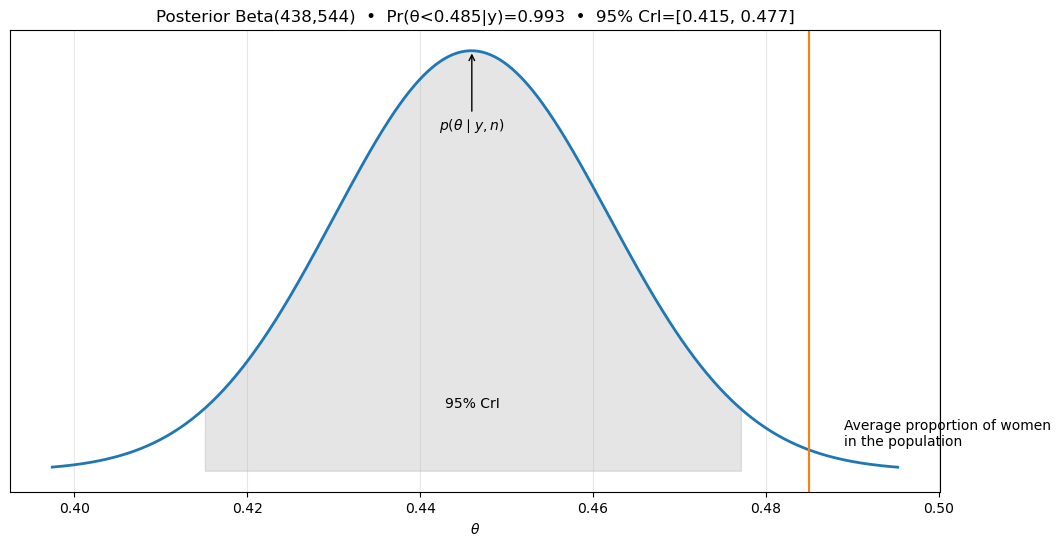

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(x, pdf, lw=2)

# Label the posterior density near its peak
i_peak = int(np.nanargmax(pdf))
ax.annotate(r'$p(\theta\mid y,n)$',
            xy=(x[i_peak], pdf[i_peak]),
            xytext=(x[i_peak], pdf[i_peak] * 0.8),
            ha='center', va='bottom',
            arrowprops=dict(arrowstyle='->', lw=1))

# Reference line at 0.485 with annotation placed at the curve height
ax.axvline(theta_ref, color='C1')
y_ref = post_u.pdf(theta_ref)
ax.annotate('Average proportion of women\nin the population',
            xy=(theta_ref, y_ref),
            xytext=(theta_ref + 0.004, y_ref * 1.05),
            ha='left', va='bottom')

# Shade the 95% credible interval region
mask_95 = (x >= cri_lo) & (x <= cri_hi)
ax.fill_between(x[mask_95], pdf[mask_95], color='gray', alpha=0.2)
ax.text(post_median, max(pdf) * 0.15, "95% CrI", ha='center')

ax.set_xlabel(r'$\theta$')
ax.axes.get_yaxis().set_visible(False)
ax.set_title(
    f"Posterior Beta({a_post_u},{b_post_u})  •  "
    f"Pr(θ<0.485|y)={tail_prob:.3f}  •  95% CrI=[{cri_lo:.3f}, {cri_hi:.3f}]"
)
plt.show()

# Example 2. Prior sensitivity in the Binomial–Beta model

We compare three **informative priors** centered at 0.485 with different **prior effective sample sizes**
$\kappa = \alpha + \beta \in \{2, 20, 200\}$. For each, we show the prior and the posterior, and print:
- posterior mean,
- 95% equal-tailed credible interval,
- `Pr(θ < 0.485 | y)`.

For context, the **uniform-prior posterior** `Beta(y+1, n−y+1)` is overlaid in every panel.


In [ ]:
# Data and reference value
y = 437
n = 980
theta_ref = 0.485

In [ ]:
# Uniform-prior posterior
a_post_u = y + 1
b_post_u = (n - y) + 1

In [ ]:
# Three informative priors centered at 0.485 with increasing strength κ
kappas = np.array([2, 20, 200], dtype=float)
a0 = theta_ref * kappas
b0 = (1 - theta_ref) * kappas

In [ ]:
# Build posteriors
posts = [beta(y + a0[i], (n - y) + b0[i]) for i in range(len(kappas))]
post_u = beta(a_post_u, b_post_u)

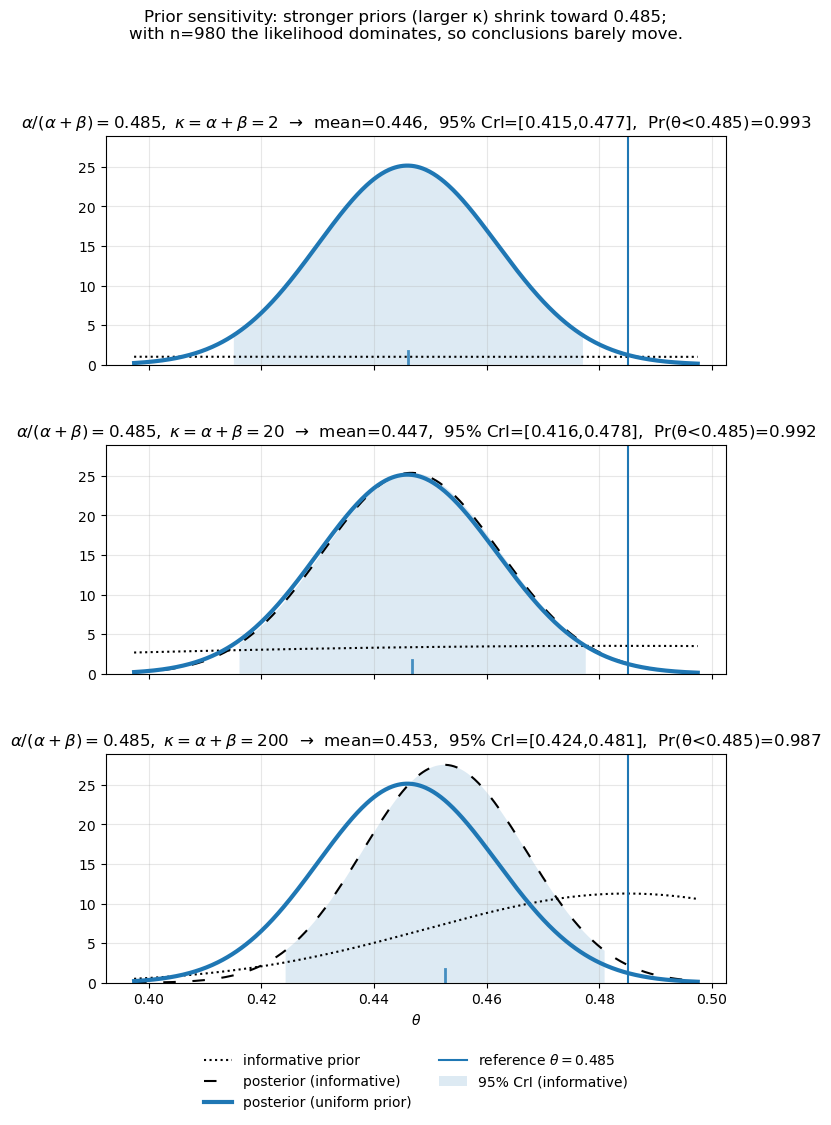

In [ ]:
all_posts = posts + [post_u]
qs = np.array([0.001, 0.999])
q_bounds = np.vstack([p.ppf(qs) for p in all_posts])
x_lo, x_hi = np.nanmin(q_bounds[:, 0]), np.nanmax(q_bounds[:, 1])
x = np.linspace(x_lo, x_hi, 600)

# Plot
fig, axes = plt.subplots(nrows=3, ncols=1, sharex=True, sharey=True, figsize=(8, 11))
fig.subplots_adjust(hspace=0.35)

for i, ax in enumerate(axes):
    prior_i = beta(a0[i], b0[i])
    post_i = posts[i]

    # Densities
    prior_line, = ax.plot(x, prior_i.pdf(x), "k:", label="informative prior")
    post_inf_line, = ax.plot(x, post_i.pdf(x), color="k", dashes=(6, 8), label="posterior (informative)")
    post_uni_line, = ax.plot(x, post_u.pdf(x), lw=3, label="posterior (uniform prior)")

    # Reference line
    ref_line = ax.axvline(theta_ref, color="C0", label=r"reference $\theta=0.485$")

    # Summaries for this panel
    mean_i = (y + a0[i]) / (n + a0[i] + b0[i])
    cri_lo_i, cri_hi_i = post_i.ppf([0.025, 0.975])
    tail_i = post_i.cdf(theta_ref)

    # Shade the 95% CrI for the informative posterior
    mask_95 = (x >= cri_lo_i) & (x <= cri_hi_i)
    ax.fill_between(x[mask_95], post_i.pdf(x)[mask_95], alpha=0.15, label="95% CrI (informative)")

    # Small tick for the posterior mean
    ax.axvline(mean_i, ymax=0.06, lw=2, alpha=0.8)

    # Clean, non-buggy title (math part + text part, no stray $)
    title_math = rf"$\alpha/(\alpha+\beta)=0.485,\ \kappa=\alpha+\beta={int(kappas[i])}$"
    title_txt  = f"  →  mean={mean_i:.3f},  95% CrI=[{cri_lo_i:.3f},{cri_hi_i:.3f}],  Pr(θ<0.485)={tail_i:.3f}"
    ax.set_title(title_math + title_txt)

axes[0].set_ylim(bottom=0)
axes[-1].set_xlabel(r"$\theta$")

# Deduplicate legend entries and place on the last subplot
handles, labels = axes[-1].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
axes[-1].legend(by_label.values(), by_label.keys(),
                loc="upper center", bbox_to_anchor=(0.5, -0.25),
                ncol=2, frameon=False)

fig.suptitle("Prior sensitivity: stronger priors (larger κ) shrink toward 0.485;\n"
             "with n=980 the likelihood dominates, so conclusions barely move.",
             y=0.995)
plt.show()

# Noninformative prior distributions

When prior distributions have no population basis, they can be difficult to construct, and there has long been a desire for prior distributions that can be guaranteed to play a minimal
role in the posterior distribution. Such distributions are sometimes called ‘reference prior distributions,’ and the prior density is described as vague, flat, diffuse or **noninformative**.

The posterior distribution is approximately that which would resultfrom assuming $p(\theta)$ is proportional to a constant for $\theta \in (−\infty, \infty)$. Such a distribution is not strictly possible, since the integral of the assumed $p(\theta)$ is infinity, which violates the assumption that probabilities sum to 1. A prior is proper iff it integrates to 1 over the parameter space.

## Uninformative Prior Distributions

"Uninformative" has a positive connotation here, implying that the use of such a prior in Bayes’ rule does not tacitly bias the resulting inference.

In the student correlation example, for instance, a uniform prior distribution for $\theta$ would not be uniform if we changed parameters to $\gamma = e^\theta$; posterior probabilities such as

$$\mathrm{Pr}\{\theta > 0|\hat\theta\} = \mathrm{Pr}\{\gamma > 1|\hat\theta\}$$

would depend on whether $\theta$ or $\gamma$ was taken to be uniform a priori. Neither choice then could be considered uninformative.

## Jeffreys’ invariance principle

A principled way to construct default (“noninformative”) priors is due to **Jeffreys**. The key idea is **invariance under smooth one-to-one reparameterizations**. If $\phi=h(\theta)$, then ordinary change of variables implies that a prior $p_\theta(\theta)$ corresponds to the prior on $\phi$
$$
p_\phi(\phi) = p_\theta(\theta)\,\Bigl|\frac{d\theta}{d\phi}\Bigr|.
$$
A good default prior should not depend on which smooth parameterization we use. Jeffreys showed that taking the prior **proportional to the square root of Fisher information** achieves this invariance.

For a one-parameter family $f(x\mid\theta)$, the (per-observation) Fisher information is
$$
J(\theta)=\mathbb{E}_\theta\!\left[\left(\frac{\partial}{\partial\theta}\log f(X\mid\theta)\right)^{\!2}\right]
= -\,\mathbb{E}_\theta\!\left[\frac{\partial^{2}}{\partial\theta^{2}}\log f(X\mid\theta)\right],
$$
and **Jeffreys’ prior** is
$$
\boxed{\pi_J(\theta)\ \propto\ \sqrt{J(\theta)}}.
$$
This prior **transforms correctly**: if $\phi=h(\theta)$ then
$$
J_\phi(\phi) = J_\theta(\theta)\,\Bigl(\frac{d\theta}{d\phi}\Bigr)^{2},
\qquad\Rightarrow\qquad
\pi_J(\phi) \propto \sqrt{J_\phi(\phi)} = \sqrt{J_\theta(\theta)}\,\Bigl|\frac{d\theta}{d\phi}\Bigr|,
$$
so $\pi_J(\phi)\,d\phi=\pi_J(\theta)\,d\theta$; the prior is the **same belief** under reparameterization.  
(For $n$ i.i.d. observations, the information is $nJ(\theta)$; the factor $n$ is constant in $\theta$ and does **not** affect $\pi_J$.)

### Example: Binomial proportion
Let $y\sim\mathrm{Bin}(n,\theta)$ with log-likelihood
$$
\log p(y\mid\theta) = \text{const} + y\,\log\theta + (n-y)\,\log(1-\theta).
$$
For a single Bernoulli trial ($n=1$),
$$
J(\theta) = \frac{1}{\theta(1-\theta)}.
$$
Thus Jeffreys’ prior is
$$
\pi_J(\theta) \ \propto\ \theta^{-1/2}(1-\theta)^{-1/2}
= \mathrm{Beta}\!\left(\tfrac12,\tfrac12\right),
$$
which is proper on $(0,1)$ and yields a proper posterior even at the boundaries $y=0$ or $y=n$:
$$
\theta \mid y \sim \mathrm{Beta}\!\left(y+\tfrac12, n-y+\tfrac12\right).
$$

*Multiparameter note:* for $\boldsymbol\theta\in\mathbb{R}^p$, Jeffreys’ generalization uses $\pi_J(\boldsymbol\theta)\propto\bigl|\mathcal I(\boldsymbol\theta)\bigr|^{1/2}$, the square root of the determinant of the Fisher information matrix.

# Example 3. Jeffreys’ prior (Binomial–Beta)

### Beta distribution recap
The **Beta function** is
$$
B(a,b)=\int_0^1 x^{a-1}(1-x)^{\,b-1}\,dx=\frac{\Gamma(a)\Gamma(b)}{\Gamma(a+b)},\qquad a,b>0.
$$
If $\Theta\sim\mathrm{Beta}(a,b)$ then
- **Mean:** $\mathbb E[\Theta]=\dfrac{a}{a+b}$
- **Variance:** $\mathrm{Var}(\Theta)=\dfrac{ab}{(a+b)^2(a+b+1)}$
- **Mode (interior):** $\dfrac{a-1}{a+b-2}$ when $a>1$ and $b>1$  
  (otherwise the mode is at a boundary, $0$ or $1$).

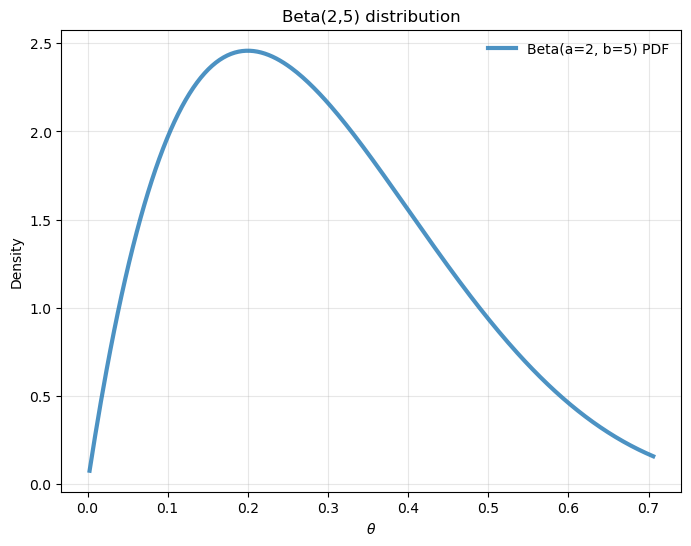

In [ ]:
a, b = 2, 5
x = np.linspace(stats.beta.ppf(0.0001, a, b), stats.beta.ppf(0.99, a, b), 300)

fig, ax = plt.subplots()
ax.plot(x, stats.beta.pdf(x, a, b), lw=3, alpha=0.8, label='Beta(a=2, b=5) PDF')
ax.set_xlabel(r'$\theta$')
ax.set_ylabel('Density')
ax.set_title('Beta(2,5) distribution')
ax.legend(frameon=False)
plt.show()

### Conjugacy for the Binomial model

With $Y\sim\mathrm{Bin}(n,\theta)$ and prior $\theta\sim\mathrm{Beta}(a,b)$ (a **conjugate** prior),
the posterior is
$$
\theta\mid Y=y \sim \mathrm{Beta}(a+y, b+n-y).
$$

Closed-form **posterior summaries**:

* Mean: $\displaystyle \mathbb E[\theta\mid y]=\frac{a+y}{a+b+n}$.
* Variance: $\displaystyle \mathrm{Var}(\theta\mid y)=\frac{(a+y),(b+n-y)}{(a+b+n)^2(a+b+n+1)}$.
* Mode (interior): $\displaystyle \frac{a+y-1}{a+b+n-2}$ if $a+y>1$ **and** $b+n-y>1$;
  otherwise the mode is at the nearest boundary.

---

### Two common default priors for a proportion

* **Uniform prior**: $\mathrm{Beta}(1,1)$ (flat on $\theta\in(0,1))$.
* **Jeffreys’ prior**: $\mathrm{Beta} \left(\tfrac12,\tfrac12\right)$ (invariant construction; yields proper posteriors even when $y=0$ or $y=n)$.

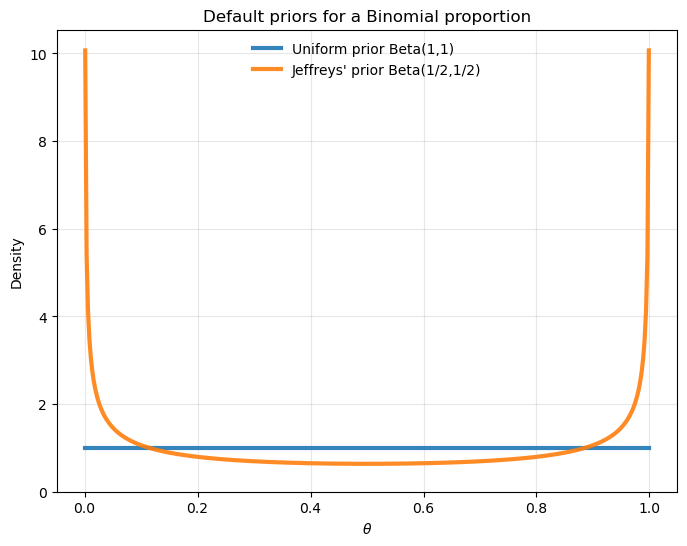

In [ ]:
# Compare Uniform vs Jeffreys priors on (0,1)
theta = np.linspace(0.001, 0.999, 400)

fig, ax = plt.subplots()
ax.plot(theta, stats.beta.pdf(theta, 1, 1), lw=3, alpha=0.9, label='Uniform prior Beta(1,1)')
ax.plot(theta, stats.beta.pdf(theta, 0.5, 0.5), lw=3, alpha=0.9, label="Jeffreys' prior Beta(1/2,1/2)")
ax.set_ylim(bottom=0)
ax.set_xlabel(r'$\theta$')
ax.set_ylabel('Density')
ax.set_title('Default priors for a Binomial proportion')
ax.legend(frameon=False)
plt.show()

In [ ]:
def mean_beta(a, b):
    return a / (a + b)

def variance_beta(a, b):
    return (a * b) / (((a + b) ** 2) * (a + b + 1))

def _wilson_ci(r, n, alpha=0.05):
    # Wilson score interval for Binomial proportion
    if n == 0:
        return (np.nan, np.nan)
    p = r / n
    z = stats.norm.ppf(1 - alpha/2)
    denom = 1 + z**2 / n
    center = (p + z**2/(2*n)) / denom
    half = z * np.sqrt(p*(1 - p)/n + z**2/(4*n**2)) / denom
    return (center - half, center + half)

def _round_ci_tuple(lo, hi, d=3):
    return (round(lo, d), round(hi, d))

def table_results(r, n, include_ci=True, alpha=0.05, ci_decimals=3):
    """
    Three estimators for a Binomial proportion:
      - Frequentist: MLE p̂ = r/n with plug-in Var[p̂] = p̂(1-p̂)/n
      - Uniform prior: Beta(1,1) -> posterior Beta(r+1, n-r+1)
      - Jeffreys prior: Beta(1/2,1/2) -> posterior Beta(r+1/2, n-r+1/2)
    Optionally adds 95% intervals: Wilson (freq), equal-tailed CrI (Bayes).
    """
    # Frequentist
    p_hat = r / n if n > 0 else np.nan
    var_hat = p_hat * (1 - p_hat) / n if n > 0 else np.nan

    # Uniform posterior parameters
    a_u, b_u = r + 1, (n - r) + 1
    mean_u = mean_beta(a_u, b_u)
    var_u  = variance_beta(a_u, b_u)

    # Jeffreys posterior parameters
    a_j, b_j = r + 0.5, (n - r) + 0.5
    mean_j = mean_beta(a_j, b_j)
    var_j  = variance_beta(a_j, b_j)

    df = pd.DataFrame(
        columns=['Frequentist', 'Uniform', 'Jeffreys'],
        index=['Estimate θ̂', 'Estimated Var(θ̂)']
    )
    df.loc['Estimate θ̂'] = [p_hat, mean_u, mean_j]
    df.loc['Estimated Var(θ̂)'] = [var_hat, var_u, var_j]

    if include_ci:
        lo_u, hi_u = stats.beta.ppf([alpha/2, 1 - alpha/2], a_u, b_u)
        lo_j, hi_j = stats.beta.ppf([alpha/2, 1 - alpha/2], a_j, b_j)
        lo_f, hi_f = _wilson_ci(r, n, alpha=alpha)
        df.loc[f'{int((1-alpha)*100)}% interval'] = [
            _round_ci_tuple(lo_f, hi_f, ci_decimals),
            _round_ci_tuple(lo_u, hi_u, ci_decimals),
            _round_ci_tuple(lo_j, hi_j, ci_decimals),
        ]

    return df

In [ ]:
table_results(1, 10)

,Frequentist,Uniform,Jeffreys
Estimate θ̂,0.1000,0.1667,0.1364
Estimated Var(θ̂),0.0090,0.0107,0.0098
95% interval,"(0.018, 0.404)","(0.023, 0.413)","(0.011, 0.381)"


In [ ]:
table_results(10, 100)

,Frequentist,Uniform,Jeffreys
Estimate θ̂,0.1000,0.1078,0.1040
Estimated Var(θ̂),0.0009,0.0009,0.0009
95% interval,"(0.055, 0.174)","(0.056, 0.175)","(0.053, 0.17)"


In [ ]:
table_results(100, 1000)

,Frequentist,Uniform,Jeffreys
Estimate θ̂,0.1000,0.1008,0.1004
Estimated Var(θ̂),0.0001,0.0001,0.0001
95% interval,"(0.083, 0.12)","(0.083, 0.12)","(0.083, 0.12)"


#### Jeffreys’ prior and transformations

Suppose we change parameters from $\mu$ to $\tilde\mu$ in a smoothly differentiable way. The new family $\tilde{f_{\tilde\mu}}(x)$ satisfies:
$$\frac{\partial}{\partial\tilde\mu}\log \tilde{f_{\tilde\mu}}(x) = \frac{\partial}{\partial\tilde\mu}\frac{\partial}{\partial\mu}\log f_\mu(x)$$

Then $\mathcal{\tilde{I_\tilde\mu}} = (\frac{\partial}{\partial\tilde\mu})^2\mathcal{I_\mu}~$ and $\mathrm{\tilde{g}^{Jeff}}(\tilde\mu) = |\frac{\partial}{\partial\tilde\mu}|\mathrm{g^{Jeff}}(\mu)$. But this just says that $\mathrm{g^{Jeff}}(\mu)$ transforms correctly to $\mathrm{\tilde{g}^{Jeff}}(\tilde\mu)$.

In this case, as in the majority of scientific situations, we don’t have a trove of relevant past experience ready to provide a prior $\mathrm{g}(\theta)$. One expedient, going back to Laplace, is the "principle of insufficient reason," that is, we take $\theta$ to be uniformly distributed over $\Omega$:
$~\mathrm{g}(\theta) = \frac{1}{2}~$ for $~-1 \leq \theta \leq 1$, a "flat prior."

# A sketch of Frequentist inference

Dataset loading:

In [ ]:
# Measurements of glomerular filtration rate for 211 kidney patients
# from the Nephrology laboratory of Dr Bryan Myers at Stanford University.
gfr = pd.read_csv("https://web.stanford.edu/~hastie/CASI_files/DATA/gfr.txt", names=['gfr'])

gfr.head()

,gfr
0,108
1,91
2,62
3,59
4,84


In [ ]:
mu_gfr = gfr.mean(axis=0).values[0]
se_gfr = gfr.sem(axis=0).values[0]
print(f'Mean: {mu_gfr}, SE: {se_gfr}')

Mean: 54.2654028436019, SE: 0.9445843621716755


$\pm 0.94$ denotes a frequentist inference for the accuracy of the estimate $\bar{x} = 54.27$. Statistical inference usually begins with the assumption that some probability model has produced the observed data $x$, in our case the vector of $n = 211$ `gfr` measurements $x = (x_1, x_2, ..., x_n)$. Let $\boldsymbol{X} = (X_1, X_2, ..., X_n)$ indicate *n* independent draws from a probability distribution $F$, written $$F \rightarrow \boldsymbol{X}$$

$F$ being the underlying distribution of possible `gfr` scores here. A realization $\boldsymbol{X} = x$ has been observed, and the statistician wishes to *infer* some property of the unknown distribution $F$.

Suppose the desired property is the *expectation* of a single random draw
$X$ from $F$, denoted $$\theta = E_F\{X\}$$

The estimate $\hat\theta$ is calculated from $x$ according to some known algorithm, say $\hat\theta = t(\boldsymbol{x})$, which in our example being the averaging function $\bar{x} = \sum{x_i/n}$; $\hat\theta$ is a realization of $$\Theta = t(\boldsymbol{X})$$

A definition of frequentist inference:
> *The accuracy of an observed estimate $\hat\theta = t(\boldsymbol{x})$ is the probabilistic accuracy of $\Theta = t(\boldsymbol{X})$ as an estimator of $\theta$*.

Bias and variance are familiar examples of frequentist inference. Define $\mu$ to be expectation of $\Theta = t(\boldsymbol{X})$, $$\mu = E_F\{\hat\Theta\}$$

Then the bias and variance attributed to estimate $\hat\theta$ of parameter $\theta$ are:

bias $= \mu - \theta$

and

var $= E_F\{(\hat\Theta\ -\mu)^2\}$

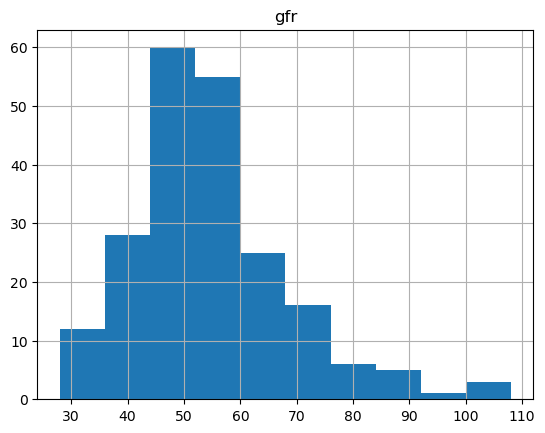

In [ ]:
gfr.hist();

# Bayesian Inference

A *family* of probability densities $$\mathcal{F} = \{f_\mu(x); x \in \mathcal{X}, \mu \in \Omega\}$$

$x$ - observed data, is a point in the *sample space* $\mathcal{X}$, while the unobserved parameter $\mu$ is a point in the *parameter space* $\Omega$. The statistician observes $x$ from $f_\mu(x)$, and infers the value of $\mu$.

Perhaps the most familiar case is the normal family: $$f_\mu(x) = \frac{1}{\sqrt2\pi}e^{-\frac{1}{2}(x-\mu)^2}$$

The Poisson family: $$f_\mu(x) = e^{-\mu}\mu^x/x!$$

Bayesian inference requires one crucial assumption in addition to the
probability family $\mathcal{F}$, the knowledge of a *prior density*: $$g(\mu), \mu \in \Omega$$

$\mathrm{g}(\mu)$ represents prior information concerning the parameter $\mu$, available to the statistician before the observation of $x$. For instance, in an application of the normal model, it could be known that is positive, while past experience shows it never exceeding 10, in which case we might take $g(\mu)$ to be the uniform density $\mathrm{g}(\mu) = 1/10$ on the interval $[0, 10]$. Exactly
what constitutes "prior knowledge" is a crucial question we will consider in ongoing discussions of Bayes’ theorem.

Bayes’ theorem is a rule for combining the prior knowledge in $\mathrm{g}(\mu)$ with the current evidence in $x$. Let $\mathrm{g}(\mu|x)$ denote the posterior density of $\mu$, that is, our update of the prior density $\mathrm{g}(\mu)$ after taking account of observation $x$. Bayes’ rule provides a simple expression for $\mathrm{g}(\mu|x)$ in terms of $\mathrm{g}(\mu)$ and $\mathcal{F}$.

Bayes' Rule:
> $\mathrm{g}(\mu|x) = \frac{\mathrm{g}(\mu)f_\mu(x)}{f(x)}$,

where $\mu \in \Omega$, and where $f(x)$ is the *marginal density* of $x$,

$$f(x) = \int_{\Omega}{f_\mu(x)\mathrm{g}(\mu)d\mu}$$

(or sum if $\Omega$ were discrete).

In Bayes’ formula, $x$ is fixed at its observed value while varies over, just the opposite of frequentist calculations. We can emphasize this by rewriting Bayes' rule as: $$\mathrm{g}(\mu|x) = c_x L_x(\mu)\mathrm{g}(\mu)$$

Where $L_x(\mu)$ is the likelihood function, that is, $f_\mu(x)$ with $x$ fixed and $\mu$ varying. Having computed $L_x(\mu)\mathrm{g}(\mu)$, the constant $c_x$ can be determined numerically from the requirement that $\mathrm{g}(\mu|x)$ integrate to 1, obviating the calculation of $f(x)$.

Multiplying the likelihood function by any fixed constant $c_0$ has no effect on the expression since $c_0$ can be absorbed into $c_x$. So for the Poisson family we can take $L_x(\mu) = e^{-\mu}\mu^x$ , ignoring the $x!$ factor, which acts as a constant in Bayes’ rule. The luxury of ignoring factors depending only on $x$ often simplifies Bayesian calculations.

For any two points $\mu_1$ and $\mu_2$ in $\Omega$, the ratio of posterior densities is:
$$\frac{\mathrm{g}(\mu_1|x)}{\mathrm{g}(\mu_2|x)} = \frac{\mathrm{g}(\mu_1)}{\mathrm{g}(\mu_2)}\cdot\frac{f_{\mu_1}(x)}{f_{\mu_2}(x)}$$

(no longer involving the marginal density $f(x)$, that is, "the posterior odds
ratio is the prior odds ratio times the likelihood ratio," a memorable restatement of Bayes’ rule.

## Example 1

A simple but genuine example of Bayes’ rule in action is provided by the story of the *Physicist’s Twins*: thanks to sonograms, a physicist found out she was going to have twin boys. "What is the probability my twins will be *Identical*, rather than *Fraternal*?" she asked. The doctor answered that one-third of twin births were Identicals, and two-thirds Fraternals.

In this situation $\mu$, the unknown parameter (or "state of nature") is either *Identical* or *Fraternal* with prior probability 1/3 or 2/3; $X$, the possible sonogram results for twin births, is either *Same Sex* or *Different Sexes*, and $x = $ *Same Sex* was observed. (We can ignore sex since that does not affect the calculation.) A crucial fact is that identical twins are always same-sex while fraternals have probability 0.5 of same or different, so *Same Sex* in the sonogram is twice as likely if the twins are Identical. Applying Bayes’ rule in ratio of posterior densities answers the physicist’s question:
$$\frac{\mathrm{g}(\mathrm{Identical}|\mathrm{Same})}{\mathrm{g}(\mathrm{Fraternal}|\mathrm{Same})} = \frac{\mathrm{g}(\mathrm{Identical})}{\mathrm{g}(\mathrm{Fraternal})}\cdot\frac{f_{\mathrm{Identical}}(\mathrm{Same})}{f_{\mathrm{Fraternal}}(\mathrm{Same})} = \frac{1/3}{2/3}\cdot\frac{1}{1/2} = 1$$

That is, the posterior odds are even, and the physicist’s twins have equal probabilities 0.5 of being Identical or Fraternal. Here the doctor’s prior odds ratio, 2 to 1 in favor of Fraternal, is balanced out by the sonogram’s likelihood ratio of 2 to 1 in favor of Identical.

<table>
  <thead>
    <tr>
      <th></th>
      <th colspan="2" scope="colgroup" style="text-align:center">Sonogram shows:</th>
      <th rowspan="2" scope="col" style="text-align:center">Doctor</th>
    </tr>
    <tr>
      <th scope="col">Twins are:</th>
      <th scope="col">Same sex</th>
      <th scope="col">Different</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th scope="row">Identical</th>
      <td style="text-align:center">1/3</td>
      <td style="text-align:center">0</td>
      <td style="text-align:center">1/3</td>
    </tr>
    <tr>
      <th scope="row">Fraternal</th>
      <td style="text-align:center">1/3</td>
      <td style="text-align:center">1/3</td>
      <td style="text-align:center">2/3</td>
    </tr>
  </tbody>
  <tfoot>
    <tr>
      <th colspan="4" style="text-align:center">Physicist</th>
    </tr>
  </tfoot>
</table>


## Example 2

Loading Student score data:

In [ ]:
scores = pd.read_csv("https://web.stanford.edu/~hastie/CASI_files/DATA/student_score.txt", sep=' ')

In [ ]:
scores

,mech,vecs,alg,analy,stat
0,7,51,43,17,22
1,44,69,53,53,53
2,49,41,61,49,64
3,59,70,68,62,56
4,34,42,50,47,29
5,46,40,47,29,17
6,0,40,21,9,14
7,32,45,49,57,64
8,49,57,47,39,26
9,52,64,60,63,54


In [ ]:
scores.corr()

,mech,vecs,alg,analy,stat
mech,1.000000,0.497807,0.756036,0.653476,0.535774
vecs,0.497807,1.000000,0.592262,0.507135,0.378604
alg,0.756036,0.592262,1.000000,0.762755,0.669825
analy,0.653476,0.507135,0.762755,1.000000,0.737671
stat,0.535774,0.378604,0.669825,0.737671,1.000000


The sample correlation coefficient between the two scores is:

$$\hat{\theta} = \frac{\sum_\limits{i=1}^{n}(m_i - \bar{m})(v_i - \bar{v})}{\sqrt{\sum_\limits{i=1}^{n}(m_i - \bar{m})^2\sum_\limits{i=1}^{n}(v_i - \bar{v})^2}}$$

with $m$ and $v$ short for mechanics and vectors, $\bar{m}$ and $\bar{v}$ their averages achieved by $n=22$ students.

If we assume that the joint $(m, v)$ distribution is bivariate normal, then the density of $\hat{\theta}$ as a function of $\theta$ has a known form:

$$f_\theta(\hat{\theta}) = \frac{(n-2)(1-\theta^2)^{(n-1)/2}(1-\hat{\theta^2})^{(n-4)/2}}{\pi}\int_\limits{0}^{\infty}\frac{dw}{(\mathrm{cosh}w -\theta\hat{\theta})^{n-1}}$$

In terms of our general Bayes notation, parameter $\mu$ is $\theta$,observation $x$ is $\hat{\theta}$ and family $\mathcal{F}$ is given by this formula, with both $\Omega$ and $\mathcal{X}$ equaling the interval $[-1,1]$.

In [ ]:
print('Theta_hat = ', np.round(scores[['mech','vecs']].corr().loc['mech','vecs'], 3))

Theta_hat =  0.498
